In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
dataset = pd.read_csv('/content/SNP.csv')
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [5]:
dataset.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [6]:
dataset.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


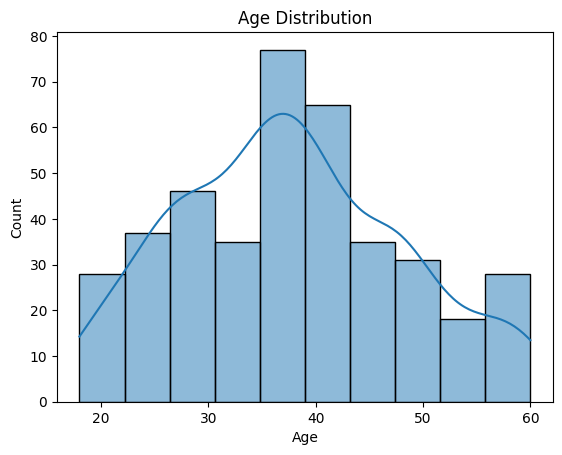

In [7]:
sns.histplot(dataset['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

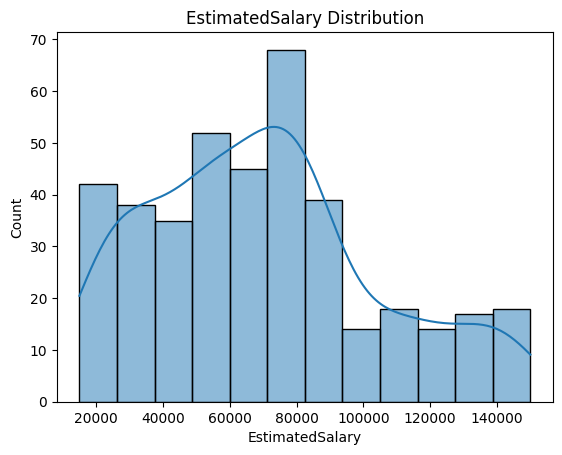

In [9]:
sns.histplot(dataset['EstimatedSalary'], kde=True)
plt.title('EstimatedSalary Distribution')
plt.show()

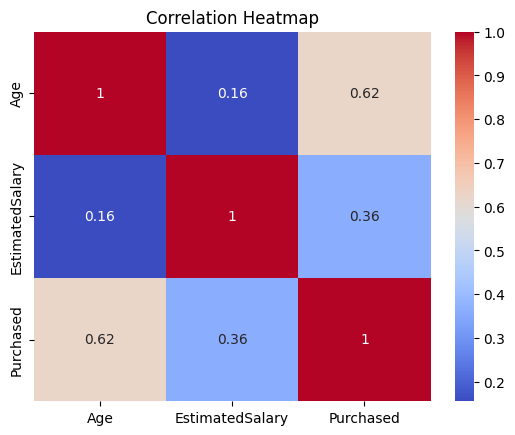

In [12]:
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

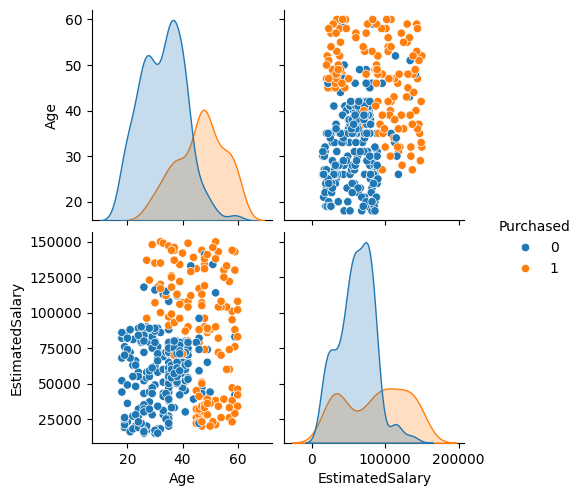

In [13]:
sns.pairplot(dataset, hue='Purchased')


In [14]:
dataset["Age_Sal_Ratio"] = dataset["Age"] / dataset["EstimatedSalary"]

In [15]:
dataset.head()

,Age,EstimatedSalary,Purchased,Age_Sal_Ratio
0,19,19000,0,0.001000
1,35,20000,0,0.001750
2,26,43000,0,0.000605
3,27,57000,0,0.000474
4,19,76000,0,0.000250


In [16]:
X = dataset[['Age','EstimatedSalary','Age_Sal_Ratio']]
y = dataset['Purchased']

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [19]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train,y_train)

LogisticRegression()

In [21]:
y_pred = classifier.predict(X_test)


In [23]:
#Model Evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,y_pred)

0.9375

In [24]:
confusion_matrix(y_test,y_pred)

array([[50,  2],
       [ 3, 25]])

In [25]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.93      0.89      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



In [26]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy',max_depth=5, random_state=0)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [27]:
y_pred_dt = model.predict(X_test)

In [28]:
accuracy_score(y_test,y_pred_dt)

0.8875

In [29]:
confusion_matrix(y_test,y_pred_dt)

array([[48,  4],
       [ 5, 23]])

In [30]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91        52
           1       0.85      0.82      0.84        28

    accuracy                           0.89        80
   macro avg       0.88      0.87      0.88        80
weighted avg       0.89      0.89      0.89        80



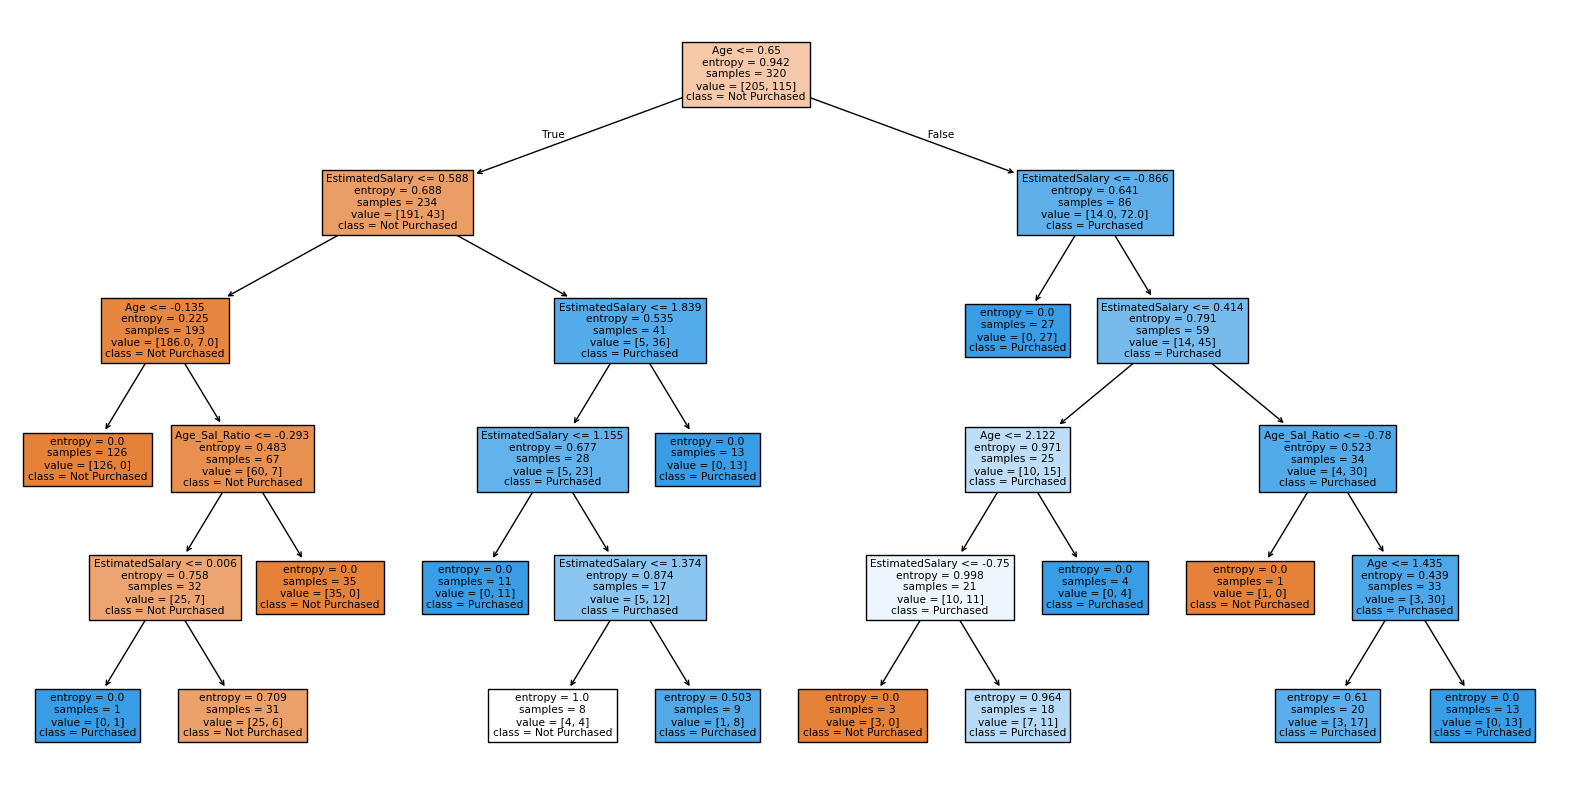

In [33]:
from sklearn import tree
plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=['Age','EstimatedSalary','Age_Sal_Ratio'],
              class_names=["Not Purchased","Purchased"], filled=True )
plt.show()

In [ ]:
Ex: Multiclass classification

In [34]:
from sklearn import datasets

In [35]:
iris = datasets.load_iris()

In [36]:
X = iris.data
y = iris.target

In [37]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [38]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.25,random_state=0)

In [42]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(
    criterion='entropy', max_depth=4, random_state=0
)
classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)

In [43]:
y_pred = classifier.predict(X_test)

In [44]:
accuracy_score(y_test,y_pred)

0.9469026548672567

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       0.86      1.00      0.93        37
           2       1.00      0.84      0.91        38

    accuracy                           0.95       113
   macro avg       0.95      0.95      0.95       113
weighted avg       0.95      0.95      0.95       113



[Text(0.3333333333333333, 0.9, 'petal width (cm) <= 0.7\nentropy = 1.584\nsamples = 37\nvalue = [12, 13, 12]'),
 Text(0.16666666666666666, 0.7, 'entropy = 0.0\nsamples = 12\nvalue = [12, 0, 0]'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'petal width (cm) <= 1.75\nentropy = 0.999\nsamples = 25\nvalue = [0, 13, 12]'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'entropy = 0.0\nsamples = 12\nvalue = [0, 12, 0]'),
 Text(0.6666666666666666, 0.5, 'sepal length (cm) <= 5.95\nentropy = 0.391\nsamples = 13\nvalue = [0, 1, 12]'),
 Text(0.5, 0.3, 'petal length (cm) <= 4.95\nentropy = 1.0\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.6666666666666666, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.8333333333333334, 0.3, 'entropy = 0.0\nsamples = 11\nvalue = [0, 0, 11]')]

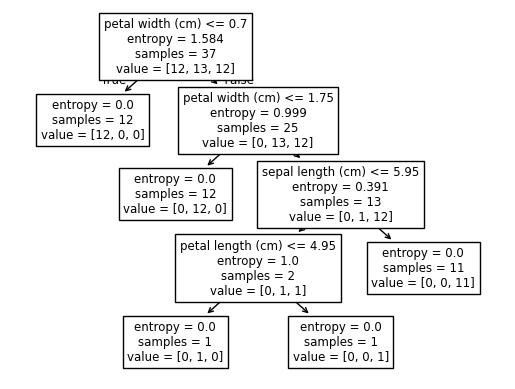

In [49]:
from sklearn import tree
tree.plot_tree(classifier, feature_names= iris.feature_names)

Ex: Decision Tree Regressor

In [50]:
dataset = pd.read_csv('/content/SNP.csv')
dataset.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [51]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [52]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [53]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [58]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(
    max_depth=3, random_state=0
)
model.fit(X_train,y_train)


DecisionTreeRegressor(max_depth=3, random_state=0)

In [59]:
y_pred_dtr = model.predict(X_test)

In [60]:
from sklearn.metrics import r2_score, mean_squared_error
r2_score(y_test,y_pred_dtr)

0.7762216771272178

In [61]:
mean_squared_error(y_test,y_pred_dtr)

0.044615803122760964